In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

###
url = "https://raw.githubusercontent.com/cesar3245/Mineria-de-datos/main/Practica%201/dataset/Police%20Data.csv"
ds = pd.read_csv(url)
###

###
ds = ds.drop(columns=['country_name', 'search_type','driver_age_raw'])

ds = ds.dropna(axis=0, how='any')

ds = ds[ds['stop_duration'] != '2']
###

###
ds['stop_date'] = pd.to_datetime(ds['stop_date'], format='%m/%d/%Y', errors='coerce')

ds['stop_year'] = ds['stop_date'].dt.year
ds['stop_month'] = ds['stop_date'].dt.month
ds['stop_day'] = ds['stop_date'].dt.day
ds['stop_wday'] = ds['stop_date'].dt.day_name()
###

###
stop_time2 = pd.to_datetime(ds['stop_time'], format='%H:%M', errors='coerce')

ds['stop_hour'] = stop_time2.dt.hour
ds['stop_minute'] = stop_time2.dt.minute
###

###
ds = ds.dropna(subset=['stop_year', 'stop_month', 'stop_day', 'stop_wday', 'stop_hour', 'stop_minute'])
###

###
ds2 = ds.drop(columns=['stop_date','stop_time'])
###

###
ds3 = ds2.copy()

ds3['search_conducted'] = ds3['search_conducted'].astype(int)
ds3['drugs_related_stop'] = ds3['drugs_related_stop'].astype(int)
ds3['driver_gender'] = ds3['driver_gender'].map({'M': 1, 'F': 0})
ds3['is_arrested'] = ds3['is_arrested'].map({'True': 1, 'False': 0, True: 1, False: 0})
###

###
ds3_cat = ds3.select_dtypes(include='object').columns.tolist()

cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ds3_cat_tr = cat_encoder.fit_transform(ds3[ds3_cat])

ds3_cat_df = pd.DataFrame(ds3_cat_tr, columns=cat_encoder.get_feature_names_out(ds3_cat), index=ds3.index)

ds4 = pd.concat([ds3.drop(columns=ds3_cat), ds3_cat_df], axis=1)
###

###
ds5 = ds4.copy()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Pronóstico próximos días:
       fecha  stops_pred
0 2012-12-08   22.217419
1 2012-12-09   22.216752
2 2012-12-10   22.216084
3 2012-12-11   22.215417
4 2012-12-12   22.214749
5 2012-12-13   22.214081
6 2012-12-14   22.213414


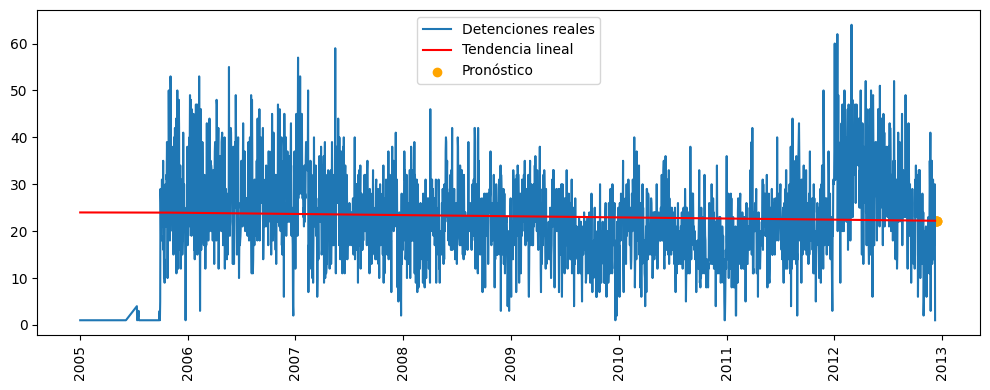

In [2]:
from sklearn.linear_model import LinearRegression

###
fechas = pd.to_datetime(dict(year=ds5['stop_year'], month=ds5['stop_month'], day=ds5['stop_day']), errors='coerce')
df = pd.DataFrame({'fecha': fechas}).dropna()
diario = (df.groupby('fecha').size().reset_index(name='stops').sort_values('fecha').reset_index(drop=True))
diario['t'] = np.arange(len(diario))
X = diario[['t']]
y = diario['stops']
###

###
modelo = LinearRegression()
modelo.fit(X, y)
diario['stops_pred'] = modelo.predict(X)
###

###
N = 7
ultimo_t = diario['t'].iloc[-1]
ultima_fecha = diario['fecha'].iloc[-1]

t_futuro = np.arange(ultimo_t + 1, ultimo_t + N + 1).reshape(-1, 1)
fechas_futuro = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=N, freq='D')

stops_futuro = modelo.predict(t_futuro)

forecast = pd.DataFrame({'fecha': fechas_futuro, 'stops_pred': stops_futuro})

print("Pronostico de los proximos dias:")
print(forecast)
###

###
plt.figure(figsize=(10, 4))
plt.plot(diario['fecha'], diario['stops'], label='Detenciones reales')
plt.plot(diario['fecha'], diario['stops_pred'], color='red', label='Tendencia lineal')
plt.scatter(forecast['fecha'], forecast['stops_pred'], color='orange', label='Pronóstico')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()
###
